# 15 · Planning chooses; trees execute

## Learning objectives

- Represent facts, preconditions, and effects.
- Find a short symbolic plan.
- Monitor execution and replan after a changed world.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A **planner** searches for actions whose effects achieve a goal. An **executor** attempts
those actions in the current world. A symbolic plan may become invalid after it is found.
Classical planning usually assumes discrete, known facts and deterministic action effects;
our robot world can violate those assumptions during execution.

**PDDL**, the Planning Domain Definition Language, separates a domain (predicates and
operators) from a problem (initial facts and a goal). We will use Python sets instead of a
parser. For example, a PDDL-like pick operator is:
```lisp
(:action pick
 :precondition (and (at-table) (detected))
 :effect (holding))
```
The following planner is breadth-first search for a tiny finite state space, not a general
PDDL solver. It finds a shortest plan in number of actions when each action has equal cost.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
from behavior_trees_tutorial.simulations.planning import Operator, plan

## Minimal working example

In [3]:
operators = [
    Operator("clear", frozenset(), frozenset({"clear"})),
    Operator("navigate", frozenset({"clear"}), frozenset({"at_table"})),
    Operator("detect", frozenset({"at_table"}), frozenset({"detected"})),
    Operator("pick", frozenset({"at_table", "detected"}), frozenset({"holding"})),
    Operator("place", frozenset({"holding"}), frozenset({"delivered"}), frozenset({"holding"})),
]
facts = {"clear"}
steps = plan(facts, {"delivered"}, operators)
print([step.name for step in steps])
assert [step.name for step in steps] == ["navigate", "detect", "pick", "place"]

['navigate', 'detect', 'pick', 'place']


## Step-by-step implementation
Compile a plan into a memory sequence. Each leaf checks its preconditions again immediately
before applying effects. We deliberately block the route after planning. Execution fails
without pretending the plan is still valid. The outer application updates facts, asks for
a new plan, and creates a fresh tree. A bounded replanning policy belongs at this level.

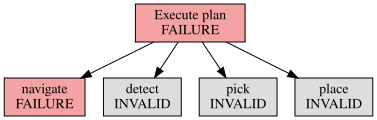

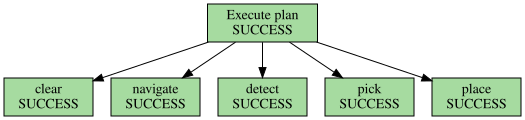

In [4]:
def execute(operator):
    if not operator.requires <= facts:
        return Status.FAILURE
    facts.difference_update(operator.deletes)
    facts.update(operator.adds)
    return Status.SUCCESS

def compile_plan(steps):
    return pt.composites.Sequence("Execute plan", memory=True, children=[
        Function(step.name, lambda step=step: execute(step)) for step in steps])

facts.remove("clear")  # An observation changed after planning.
root = compile_plan(steps)
root.tick_once()
assert root.status is Status.FAILURE
display(diagram(root))
steps = plan(facts, {"delivered"}, operators)
assert steps[0].name == "clear"
root = compile_plan(steps)
root.tick_once()
assert "delivered" in facts
display(diagram(root))

## Interactive demonstration

In [5]:
import ipywidgets as widgets

@widgets.interact(route_clear=True)
def replan(route_clear=True):
    facts.clear()
    if route_clear:
        facts.add("clear")
    steps = plan(facts, {"delivered"}, operators)
    print("Plan:", [step.name for step in steps])
    tree = compile_plan(steps)
    tree.tick_once()
    display(diagram(tree))

interactive(children=(Checkbox(value=True, description='route_clear'), Output()), _dom_classes=('widget-intera…

## Key observations

Plan validity depends on current facts. BTs provide execution and recovery policy; they do not automatically solve a planning problem.

## Exercises

1. Remove the clear operator and test an unreachable goal (None).
2. Add action costs and explain why breadth-first search no longer minimizes cost.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 15).

## Summary

Planning and execution can cooperate through explicit action contracts. The same boundary helps when a language model proposes work.